In [1]:
from src.analyse_equations.analyse_equations import add_all_data_error, print_units_of_one_equation
from src.analyse_equations.analyse_equations import set_pandas_options, create_error_table
from src.analyse_equations.analyse_equations import add_n_fold_error

from src.analyse_equations.add_information_to_equations import add_proposed_equations

from src.analyse_equations.plot_error_per_system import plot_error_per_system
from src.analyse_equations.plot_predictions_of_one_equation import plot_prediction
from src.analyse_equations.utils import save_proposed_equation, get_data_folds, load_proposed_equations

from src.config.config_equations_for_each_dataset import ConfigEquationDiscovery
from src.equation_discovery.evaluate_equation import map_equation_to_syntax_tree

from src.preprocess_data.preprocess_data import prepare_dataset, get_unit_dict
from src.config.config_analyse_equations import ConfigPlotBestEquation
from src.config.config_load_dataset import ConfigLoadData
from src.SyntaxTree.src.syntax_tree.config_syntax_tree import ConfigSyntaxTree
from src.config.config_hyperparameter import ConfigHyperparameter
import logging
from src.analyse_equations.create_constant_table import create_constant_table
from src.analyse_equations.plot_abs_difference_between_equation import abs_difference_between_equation
from src.analyse_equations.plot_histogram_for_features import histogram_for_features
from src.analyse_equations.plot_error_per_system import heatmap_error_per_system, save_system_error_heatmap
from src.analyse_equations.create_constant_table import save_constant_table

# Configs

In [2]:
logger = logging.getLogger(__name__)
set_pandas_options()

parser = ConfigHyperparameter.arguments_parser()
parser = ConfigLoadData.arguments_parser(parser)
parser = ConfigEquationDiscovery.arguments_parser(parser)
parser = ConfigPlotBestEquation.arguments_parser(parser)
parser = ConfigSyntaxTree.arguments_parser(parser)
args, unknown = parser.parse_known_args()
args.save_path = args.ROOT_DIR / f'results/{args.save_set_folder}/equation_set_{args.exp_name}.json'
args.unit_dict = get_unit_dict(args)
args.unit_dict['y'] = args.unit_dict[args.target]
args.unit_dimension = 5
measurement_error_dic = {
    'drop_length': 0.000042,
    'adv': 0.07696902,
    'rec': 0.03298672,
    'avg_vel': 0.0021,
    'width': 0.00005,
    'y_center':0.000003,
    'middle_angle': 0.03141593,
    'x_center': 0.0000042,
    'static_adv': 0.01570796,
    'static_rec': 0.01570796
}
logging.basicConfig(level=logging.INFO)


# Results to load

In [3]:
proposed_equations = load_proposed_equations(args)
add_proposed_equations(args, proposed_equations)

#files_test, files_train = get_train_test_files(args, proposed_equations)
folds_dict = get_data_folds(args, proposed_equations)
all_files = []
for excel_name, files in folds_dict.items():
    all_files.extend(files)

Load proposed equations from: /home/jbrugger/PycharmProjects/EquatationDiscoveryDropFriction/results/Sajjad_Smoothed/equation_set_ID_error_per_dataset.json
Loading 0/11 results from: results/Sajjad_Smoothed/02_Jun_2025_23:47:32_best_models_NGED.json
Loading 1/11 results from: results/Sajjad/04_Apr_2025_09:07:37_best_models_1c_50_interations.json
Loading 2/11 results from: results/Xiaomei/28_Mär_2025_11:41:26_best_models_1c_50_interations.json
Loading 3/11 results from: results/Xiaomei/28_Mär_2025_12:07:31_best_models_1c_50_interations.json
Loading 4/11 results from: results/Xiaomei/01_Apr_2025_17:12:42_best_models_1c_50_interations.json
Loading 5/11 results from: results/Xiaomei/01_Apr_2025_18:10:55_best_models_1c_50_interations.json
Loading 6/11 results from: results/Xiaomei/01_Apr_2025_20:15:19_best_models_1c_50_interations.json
Loading 7/11 results from: results/Xiaomei/01_Apr_2025_20:45:29_best_models_1c_50_interations.json
Loading 8/11 results from: results/Xiaomei/02_Apr_2025_18:

# Cross Validation

In [4]:
filtered_dfs_test, filtered_dfs_train, tree = add_n_fold_error(args, folds_dict, measurement_error_dic, proposed_equations)
save_proposed_equation(args, folds_dict, proposed_equations)

INFO:src.analyse_equations.analyse_equations:Fold 0
INFO:src.analyse_equations.analyse_equations:Fold 1
INFO:src.analyse_equations.analyse_equations:Fold 2
INFO:src.analyse_equations.analyse_equations:Equations removed cause of Unit Error: 216
INFO:src.analyse_equations.analyse_equations:Equations removed cause of MaxDepthError: 0
INFO:src.analyse_equations.analyse_equations:Equations removed cause of Overflow: 0
INFO:src.analyse_equations.analyse_equations:Equations removed cause of other Error: 25
INFO:src.analyse_equations.analyse_equations:Equations kept : 353


Proposed Equations are saved to: /home/jbrugger/PycharmProjects/EquatationDiscoveryDropFriction/results/Sajjad_Smoothed/equation_set_ID_error_per_dataset.json


# Calculate Error over all data

In [5]:
all_data_dfs = prepare_dataset(args, all_files)
add_all_data_error(all_data_dfs, args, proposed_equations)

# Create error table

In [6]:
num_variables = 2
df_error = create_error_table(args, num_variables, proposed_equations, metric='error')
df_error

INFO:src.analyse_equations.analyse_equations:table with errors saved @/home/jbrugger/PycharmProjects/EquatationDiscoveryDropFriction/plots/ID_error_per_dataset/table_with_equations_error.tex


                                                                      equation                                                                                                                                                                        infix fold mean train error fold mean test error train all error error calc. std  rank
96                                                      +  * c  * mid rec   c                                                                                                                             ( ( c_0 * (  ( mid )  *  ( rec )  )  )  +  c_1 )               8.57e-06             8.57e-06              8.62e-06  2.50e-06     0
292                                          +  *  ** adv 2  c   * avg_vel c                                                                                                       ( (    ( adv )   ** (  ( 2 )  )  * c_0 )  +  (  ( avg_vel )  * c_1 )  )               8.59e-06             8.59e-06              8.67e-06  4.91e-06     1
2

,equation,infix,fold mean train error,fold mean test error,train all error error,calc. std,rank
96,+ * c * mid rec c,( ( c_0 * ( ( mid ) * ( rec ) ) ) + c_1 ),8.57e-06,8.57e-06,8.62e-06,2.50e-06,0
292,+ * ** adv 2 c * avg_vel c,( ( ( adv ) ** ( ( 2 ) ) * c_0 ) + ( ( avg_vel ) * c_1 ) ),8.59e-06,8.59e-06,8.67e-06,4.91e-06,1
264,* c exp * - 0 1 * 27 * ** c 3 * ** rec 3 width,( c_0 * exp ( ( ( ( 0 ) - ( 1 ) ) * ( ( 27 ) * ( c_1 ** ( ( 3 ) ) * ( ( rec ) ** ( ( 3 ) ) * ( width ) ) ) ) ) ) ),8.84e-06,8.84e-06,8.87e-06,inf,2
36,* y_center / + * ** avg_vel 2 c y_center c,( ( y_center ) * ( ( ( ( avg_vel ) ** ( ( 2 ) ) * c_0 ) + ( y_center ) ) / c_1 ) ),8.86e-06,8.86e-06,8.99e-06,1.76e-07,3
279,* c / drop_length width,( c_0 * ( ( drop_length ) / ( width ) ) ),8.94e-06,8.94e-06,9.00e-06,1.28e-06,4
34,* y_center / + * ** avg_vel 2 c width c,( ( y_center ) * ( ( ( ( avg_vel ) ** ( ( 2 ) ) * c_0 ) + ( width ) ) / c_1 ) ),8.89e-06,8.89e-06,9.02e-06,1.67e-07,5
99,+ * - 0 1 c / c mid,( ( ( ( 0 ) - ( 1 ) ) * c_0 ) + ( c_1 / ( mid ) ) ),8.93e-06,8.93e-06,9.04e-06,0.00e+00,6
285,* c * drop_length sin + c rec,( c_0 * ( ( drop_length ) * sin ( ( c_1 + ( rec ) ) ) ) ),9.03e-06,9.03e-06,9.09e-06,3.10e-06,7
186,+ * ** adv 3 * c exp * - 0 1 rec * avg_vel / c rec,( ( ( adv ) ** ( ( 3 ) ) * ( c_0 * exp ( ( ( ( 0 ) - ( 1 ) ) * ( rec ) ) ) ) ) + ( ( avg_vel ) * ( c_1 / ( rec ) ) ) ),9.10e-06,9.10e-06,9.16e-06,5.88e-06,8
4,+ c * friction_coef * width * viscosity avg_vel,( c_0 + ( ( friction_coef ) * ( ( width ) * ( ( viscosity ) * ( avg_vel ) ) ) ) ),9.15e-06,9.15e-06,9.20e-06,8.56e-07,9


In [7]:
num_variables = 2
df_error = create_error_table(args, num_variables, proposed_equations, metric='error_mse')
df_error

INFO:src.analyse_equations.analyse_equations:table with errors saved @/home/jbrugger/PycharmProjects/EquatationDiscoveryDropFriction/plots/ID_error_per_dataset/table_with_equations_error_mse.tex


                                                                      equation                                                                                                                                                                        infix fold mean train error_mse fold mean test error_mse train all error error_mse calc. std  rank
292                                          +  *  ** adv 2  c   * avg_vel c                                                                                                       ( (    ( adv )   ** (  ( 2 )  )  * c_0 )  +  (  ( avg_vel )  * c_1 )  )                   1.78e-10                 1.78e-10                  1.83e-10  4.91e-06     0
96                                                      +  * c  * mid rec   c                                                                                                                             ( ( c_0 * (  ( mid )  *  ( rec )  )  )  +  c_1 )                   1.82e-10                 1.82e-10        

,equation,infix,fold mean train error_mse,fold mean test error_mse,train all error error_mse,calc. std,rank
292,+ * ** adv 2 c * avg_vel c,( ( ( adv ) ** ( ( 2 ) ) * c_0 ) + ( ( avg_vel ) * c_1 ) ),1.78e-10,1.78e-10,1.83e-10,4.91e-06,0
96,+ * c * mid rec c,( ( c_0 * ( ( mid ) * ( rec ) ) ) + c_1 ),1.82e-10,1.82e-10,1.84e-10,2.50e-06,1
34,* y_center / + * ** avg_vel 2 c width c,( ( y_center ) * ( ( ( ( avg_vel ) ** ( ( 2 ) ) * c_0 ) + ( width ) ) / c_1 ) ),1.82e-10,1.82e-10,1.87e-10,1.67e-07,2
99,+ * - 0 1 c / c mid,( ( ( ( 0 ) - ( 1 ) ) * c_0 ) + ( c_1 / ( mid ) ) ),1.85e-10,1.85e-10,1.89e-10,0.00e+00,3
36,* y_center / + * ** avg_vel 2 c y_center c,( ( y_center ) * ( ( ( ( avg_vel ) ** ( ( 2 ) ) * c_0 ) + ( y_center ) ) / c_1 ) ),1.84e-10,1.84e-10,1.90e-10,1.76e-07,4
279,* c / drop_length width,( c_0 * ( ( drop_length ) / ( width ) ) ),1.86e-10,1.86e-10,1.90e-10,1.28e-06,5
264,* c exp * - 0 1 * 27 * ** c 3 * ** rec 3 width,( c_0 * exp ( ( ( ( 0 ) - ( 1 ) ) * ( ( 27 ) * ( c_1 ** ( ( 3 ) ) * ( ( rec ) ** ( ( 3 ) ) * ( width ) ) ) ) ) ) ),1.95e-10,1.95e-10,1.97e-10,inf,6
285,* c * drop_length sin + c rec,( c_0 * ( ( drop_length ) * sin ( ( c_1 + ( rec ) ) ) ) ),1.94e-10,1.94e-10,1.97e-10,3.10e-06,7
186,+ * ** adv 3 * c exp * - 0 1 rec * avg_vel / c rec,( ( ( adv ) ** ( ( 3 ) ) * ( c_0 * exp ( ( ( ( 0 ) - ( 1 ) ) * ( rec ) ) ) ) ) + ( ( avg_vel ) * ( c_1 / ( rec ) ) ) ),1.99e-10,1.99e-10,2.01e-10,5.88e-06,8
122,/ drop_length * c * rec y_center,( ( drop_length ) / ( c_0 * ( ( rec ) * ( y_center ) ) ) ),2.01e-10,2.01e-10,2.02e-10,2.25e-07,9


In [8]:
num_variables = 2
df_error = create_error_table(args, num_variables, proposed_equations, metric='err_rel')
df_error

INFO:src.analyse_equations.analyse_equations:table with errors saved @/home/jbrugger/PycharmProjects/EquatationDiscoveryDropFriction/plots/ID_error_per_dataset/table_with_equations_err_rel.tex


                                                                      equation                                                                                                                                                                        infix fold mean train err_rel fold mean test err_rel train all error err_rel calc. std  rank
292                                          +  *  ** adv 2  c   * avg_vel c                                                                                                       ( (    ( adv )   ** (  ( 2 )  )  * c_0 )  +  (  ( avg_vel )  * c_1 )  )                 8.67e+03               8.67e+03                8.74e+03  4.91e-06     0
96                                                      +  * c  * mid rec   c                                                                                                                             ( ( c_0 * (  ( mid )  *  ( rec )  )  )  +  c_1 )                 8.74e+03               8.74e+03                8.79e+03

,equation,infix,fold mean train err_rel,fold mean test err_rel,train all error err_rel,calc. std,rank
292,+ * ** adv 2 c * avg_vel c,( ( ( adv ) ** ( ( 2 ) ) * c_0 ) + ( ( avg_vel ) * c_1 ) ),8.67e+03,8.67e+03,8.74e+03,4.91e-06,0
96,+ * c * mid rec c,( ( c_0 * ( ( mid ) * ( rec ) ) ) + c_1 ),8.74e+03,8.74e+03,8.79e+03,2.50e-06,1
34,* y_center / + * ** avg_vel 2 c width c,( ( y_center ) * ( ( ( ( avg_vel ) ** ( ( 2 ) ) * c_0 ) + ( width ) ) / c_1 ) ),8.84e+03,8.84e+03,8.95e+03,1.67e-07,2
36,* y_center / + * ** avg_vel 2 c y_center c,( ( y_center ) * ( ( ( ( avg_vel ) ** ( ( 2 ) ) * c_0 ) + ( y_center ) ) / c_1 ) ),8.84e+03,8.84e+03,8.95e+03,1.76e-07,3
279,* c / drop_length width,( c_0 * ( ( drop_length ) / ( width ) ) ),8.88e+03,8.88e+03,8.96e+03,1.28e-06,4
99,+ * - 0 1 c / c mid,( ( ( ( 0 ) - ( 1 ) ) * c_0 ) + ( c_1 / ( mid ) ) ),8.89e+03,8.89e+03,9.00e+03,0.00e+00,5
264,* c exp * - 0 1 * 27 * ** c 3 * ** rec 3 width,( c_0 * exp ( ( ( ( 0 ) - ( 1 ) ) * ( ( 27 ) * ( c_1 ** ( ( 3 ) ) * ( ( rec ) ** ( ( 3 ) ) * ( width ) ) ) ) ) ) ),9.08e+03,9.08e+03,9.12e+03,inf,6
4,+ c * friction_coef * width * viscosity avg_vel,( c_0 + ( ( friction_coef ) * ( ( width ) * ( ( viscosity ) * ( avg_vel ) ) ) ) ),9.09e+03,9.09e+03,9.14e+03,8.56e-07,7
35,* 2 * ** drop_length 2 + avg_vel c,( ( 2 ) * ( ( drop_length ) ** ( ( 2 ) ) * ( ( avg_vel ) + c_0 ) ) ),9.16e+03,9.16e+03,9.21e+03,1.38e-06,8
285,* c * drop_length sin + c rec,( c_0 * ( ( drop_length ) * sin ( ( c_1 + ( rec ) ) ) ) ),9.19e+03,9.19e+03,9.28e+03,3.10e-06,9


# Create constant table

In [9]:
index = 174
create_constant_table( all_data_dfs,
        args,
        df_error.loc[index].loc['equation'],
        proposed_equations)

,c_0,viscosity,friction_coef,gamma
20-Glycerol-Teflon-Au,-1.59e-06,1.70e-03,5.90e+01,7.00e-02
30-Glycerol-Teflon-Au,-1.55e-06,2.50e-03,5.60e+01,6.90e-02
40-Glycerol-Teflon-Au,-1.56e-06,3.80e-03,4.10e+01,6.90e-02
50-Glycerol-hydrophobic,2.21e-08,1.42e-01,2.55e-02,6.80e-02
70-Glycerol-hydrophobic,-1.78e-08,1.78e-02,5.08e-01,6.60e-02
90-Glycerol-hydrophobic,5.82e-08,5.97e-03,1.16e+01,6.50e-02
Fthiols-Au,-1.34e-06,9.20e-04,5.60e+01,7.20e-02
PFOTS-Si-water,-1.89e-06,9.20e-04,9.60e+01,7.20e-02
corr_c0,1.00e+00,5.55e-01,-9.29e-01,-8.33e-01


# Create heat map local

| * c  /  +  *  - 0 1 adv  rec  drop_length  |
|+ c * friction_coef * width * viscosity avg_vel|
| * c  /  **  + adv  sin  ** rec 2   3  rec  |
| *  - 0 1  * c  / c  ** rec 2    |
| * 2  * drop_length  /  +  * c width  drop_length  c   |
| + c * c * width - cos rec  cos adv |
Heatmap saved to /home/jbrugger/PycharmProjects/EquatationDiscoveryDropFriction/plots/ID_error_per_dataset/error_per_system_heatmap.pdf


/home/jbrugger/PycharmProjects/EquatationDiscoveryDropFriction/src/analyse_equations/plot_error_per_system.py:78: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


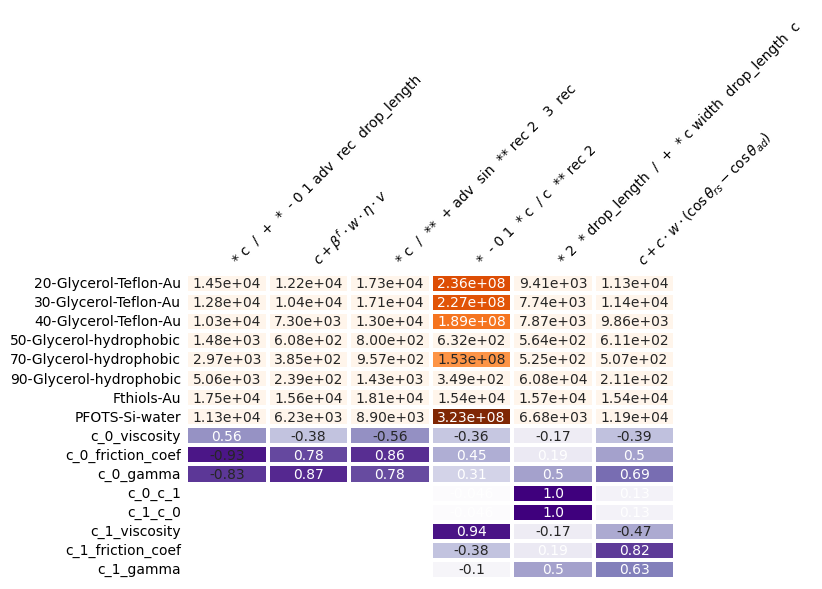

In [10]:

import pandas as pd

indices = [174, 4, 29 ,87, 39, 5]
metric = 'err_rel'





pd_dict = heatmap_error_per_system(
        all_data_dfs,
        args,
        df_error,
        proposed_equations,
        indices,
        metric
    )
pd.DataFrame(pd_dict)
save_system_error_heatmap(args, pd_dict)

### Create constant table

In [11]:
index = 174
pd_constants = create_constant_table(
    all_data_dfs,
    args,
    df_error.loc[index].loc['equation'],
    proposed_equations
)
save_constant_table(args, logger, pd_constants)
pd_constants

INFO:__main__:table with constants saved @ /home/jbrugger/PycharmProjects/EquatationDiscoveryDropFriction/plots/ID_error_per_dataset/table_with_constants.tex


,c_0,viscosity,friction_coef,gamma
20-Glycerol-Teflon-Au,-1.59e-06,1.70e-03,5.90e+01,7.00e-02
30-Glycerol-Teflon-Au,-1.55e-06,2.50e-03,5.60e+01,6.90e-02
40-Glycerol-Teflon-Au,-1.56e-06,3.80e-03,4.10e+01,6.90e-02
50-Glycerol-hydrophobic,2.21e-08,1.42e-01,2.55e-02,6.80e-02
70-Glycerol-hydrophobic,-1.78e-08,1.78e-02,5.08e-01,6.60e-02
90-Glycerol-hydrophobic,5.82e-08,5.97e-03,1.16e+01,6.50e-02
Fthiols-Au,-1.34e-06,9.20e-04,5.60e+01,7.20e-02
PFOTS-Si-water,-1.89e-06,9.20e-04,9.60e+01,7.20e-02
corr_c0,1.00e+00,5.55e-01,-9.29e-01,-8.33e-01


## Print units

In [12]:
index = 174
print_units_of_one_equation(args, df_error, index, proposed_equations)

INFO:src.analyse_equations.analyse_equations:('y', '( c_0 * ( ( ( (  ( 0 )  -  ( 1 )  )  *  ( adv )  )  +   ( rec )  )  /  ( drop_length )  )  ) ')


d: 0  id: 0.0   *	 m^1.0 * s^-2.0 * kg^1.0
d: 1  id: 1.0   	c_0	 m^2.0 * s^-2.0 * kg^1.0
d: 1  id: 512.0 	/	 m^-1.0
d: 2  id: 513.0 		+	 
d: 3  id: 514.0 			*	 
d: 4  id: 515.0 				-	 
d: 5  id: 516.0 					0	 
d: 5  id: 547.0 					1	 
d: 4  id: 578.0 				adv	 
d: 3  id: 641.0 			rec	 
d: 2  id: 768.0 		drop_length	 m^1.0


In [13]:
# Plot prediction

Saving prediction plot to: /home/jbrugger/PycharmProjects/EquatationDiscoveryDropFriction/plots/ID_error_per_dataset/equations/prediction_( c_0 +  ( c_1 * (  ( width )  * (  cos ( ( rec )  ) -  cos ( ( adv )  ) )  )  )  ) .pdf


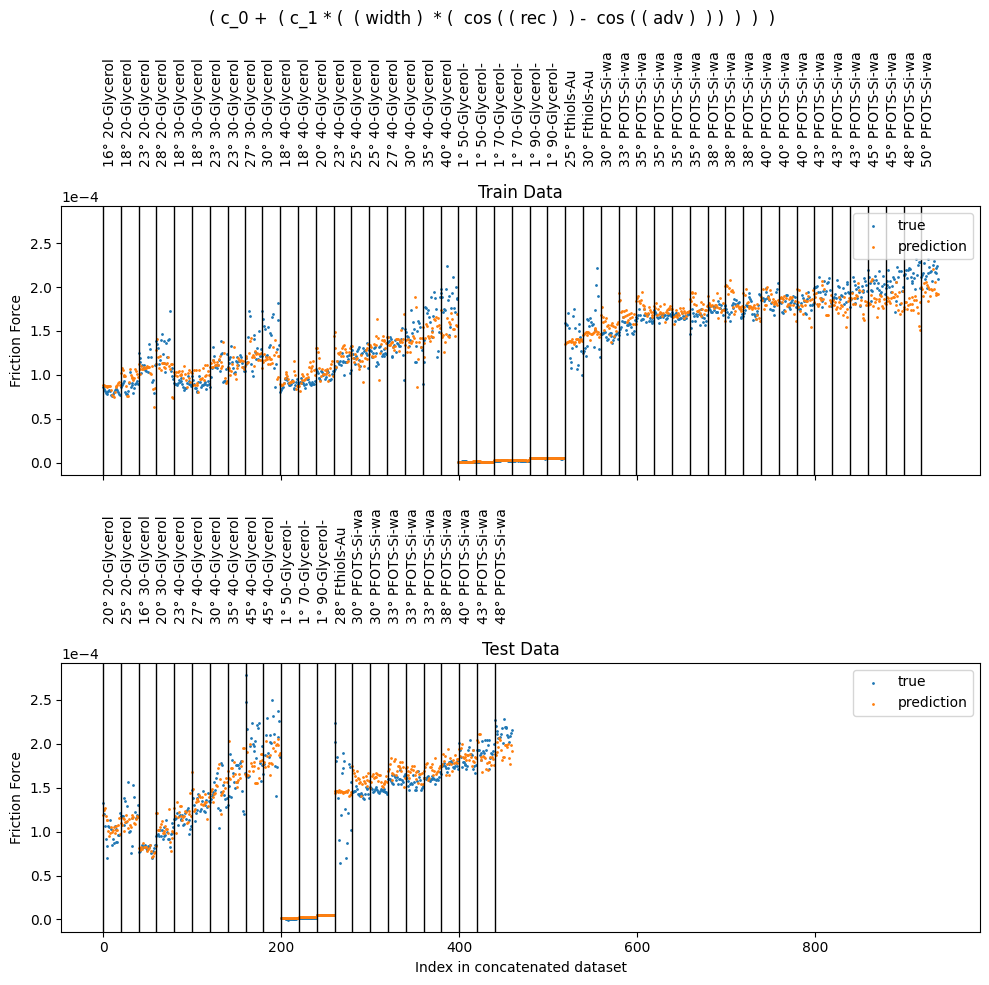

In [14]:
index =5
equation = proposed_equations[df_error.loc[index].loc['equation']]
tree = map_equation_to_syntax_tree(args, df_error.loc[index].loc['equation'], infix=False, catch_exceptions=False)
tree.constants_in_tree = equation['all_data']['train']['constants']
plot_prediction(args, filtered_dfs_test, filtered_dfs_train, tree)

## Error per system

/home/jbrugger/PycharmProjects/EquatationDiscoveryDropFriction/src/analyse_equations/plot_error_per_system.py:49: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


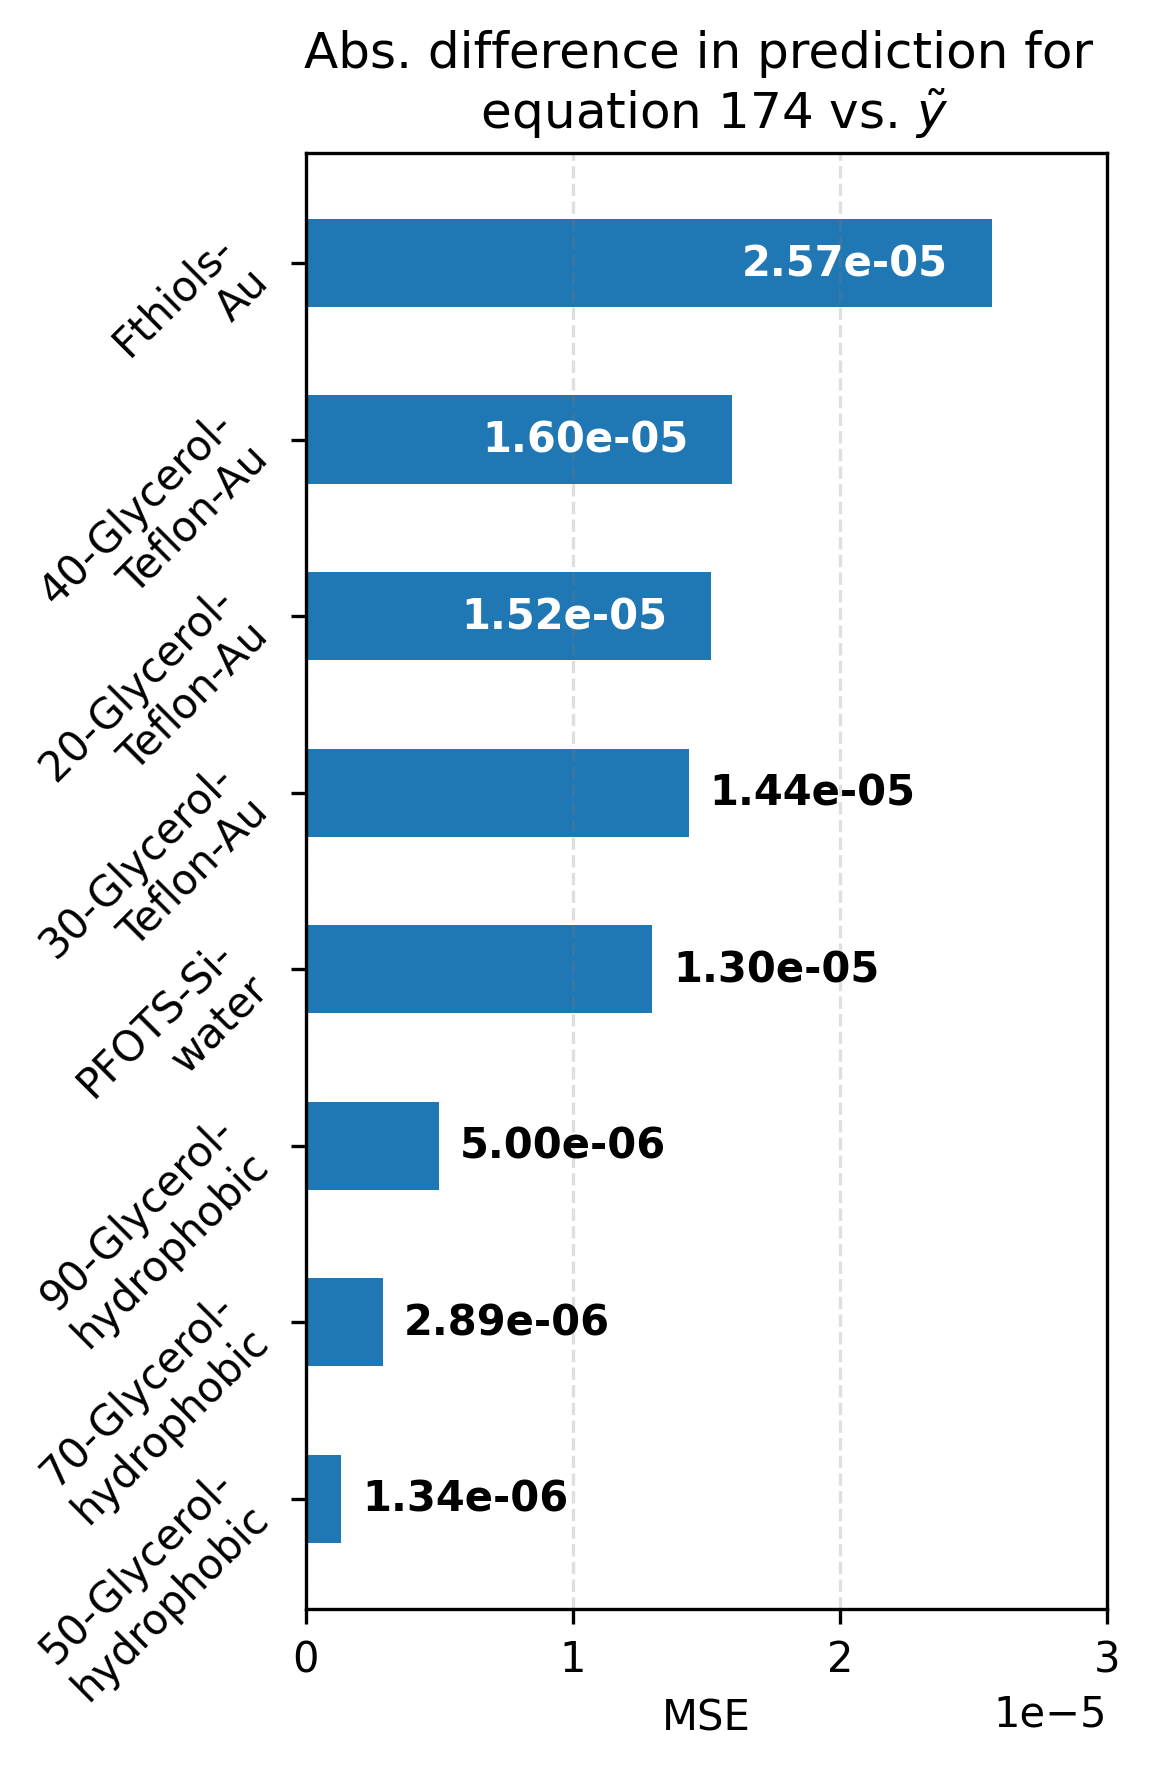

In [15]:
index = 174
plot_error_per_system(args, df_error, index, proposed_equations)

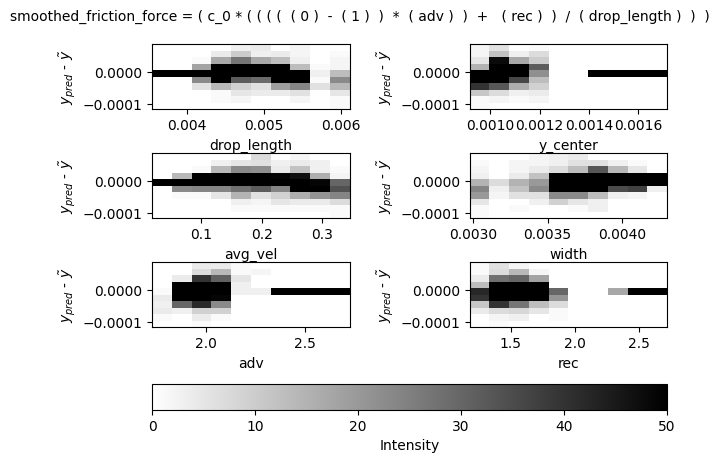

In [16]:



########################################
############ histogram #############
########################################
args.features = ['drop_length', 'y_center','avg_vel', 'width','adv', 'rec']


index = 174
equation = proposed_equations[df_error.loc[index].loc['equation']]
tree = map_equation_to_syntax_tree(args, df_error.loc[index].loc['equation'], infix=False, catch_exceptions=False)
tree.constants_in_tree = equation['all_data']['train']['constants']
histogram_for_features(args, all_data_dfs, tree)

/home/jbrugger/PycharmProjects/EquatationDiscoveryDropFriction/src/analyse_equations/plot_abs_difference_between_equation.py:58: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


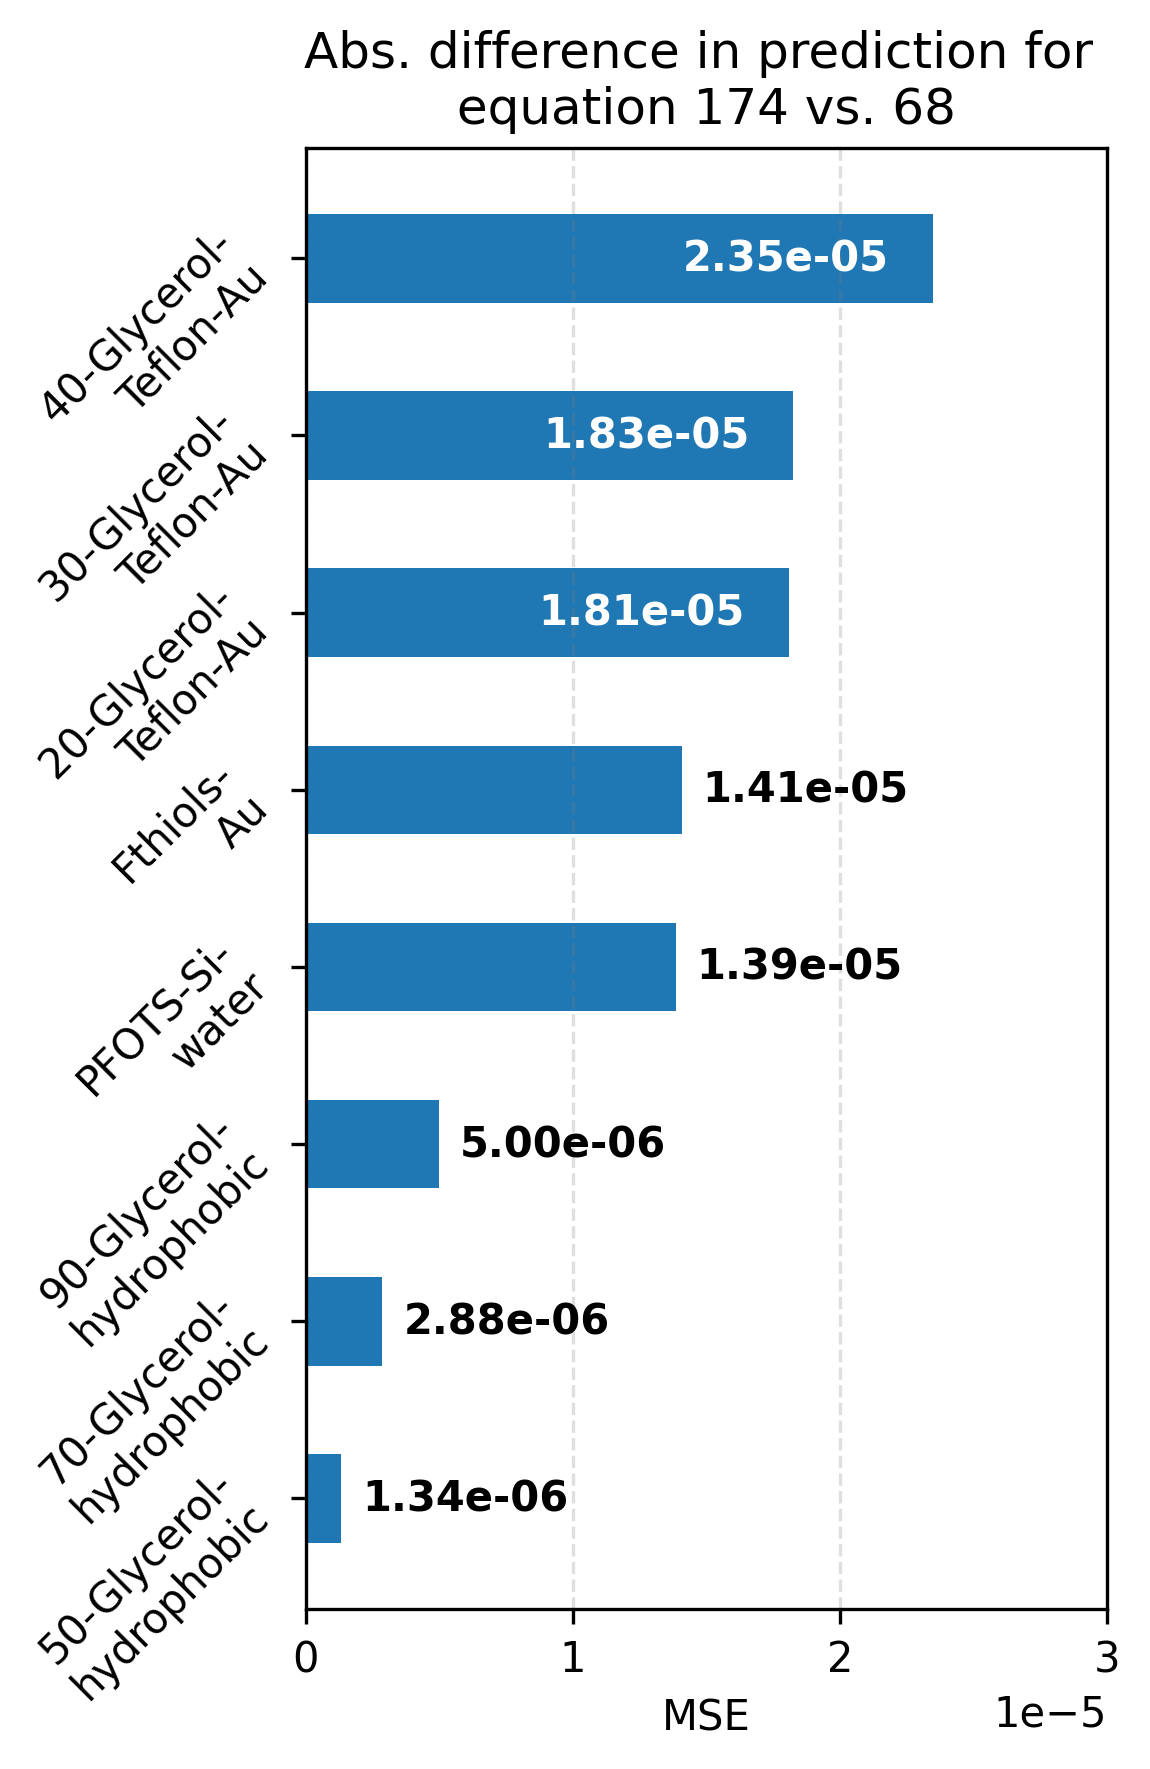

In [17]:
########################################
###### difference between two eq #######
########################################
index_0 = 174
index_1 = 68
abs_difference_between_equation(args, proposed_equations, df_error, all_data_dfs, index_0, index_1)
